# 01 — Annual dataset composition

This notebook reproduces the annual composition of the analytical sample
along the three focal dimensions used in the manuscript:

1. first-author academic age;
2. first-author language environment; and
3. conference track type.

Missing or invalid values are excluded separately for each dimension.
Consequently, every annual percentage uses papers with a valid value for
that dimension as its denominator. The workflow deliberately separates
source-data construction from plotting: the source-data tables are written
to `data/source_data/01_dataset_composition/`, and the following cells read
those tables to display the figures. Figures are shown in the notebook only
and are not saved to disk.

In [15]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)

YEARS = list(range(2020, 2026))

# Locate the repository robustly whether Jupyter starts in the repository
# root or in code_analysis/.
search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        path
        for path in search_roots
        if (path / "data/processed/id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current "
        f"working directory: {Path.cwd()}"
    )

INPUT_CSV = REPO_ROOT / "data/processed/id_papers.csv"
SOURCE_DATA_DIR = REPO_ROOT / "data/source_data/01_dataset_composition"
SOURCE_DATA_DIR.mkdir(parents=True, exist_ok=True)

DIMENSIONS = {
    "academic_age": {
        "column": "academic_age_group",
        "categories": ["0–3 years", "4–10 years", "11+ years"],
        "colors": ["#D9D2EA", "#9A86C8", "#574B8A"],
        "title": "First-author academic age",
        "filename": "academic_age_composition.csv",
    },
    "language_environment": {
        "column": "language_environment_group",
        "categories": ["English", "Non-English"],
        "colors": ["#3775BA", "#D89164"],
        "title": "First-author language environment",
        "filename": "language_environment_composition.csv",
    },
    "track_type": {
        "column": "track_group",
        "categories": ["Main track", "Non-main track"],
        "colors": ["#0F4D92", "#8BCF8B"],
        "title": "Conference track type",
        "filename": "track_type_composition.csv",
    },
}

print(f"Repository root: {REPO_ROOT}")
print(f"Input data: {INPUT_CSV}")
print(f"Source-data directory: {SOURCE_DATA_DIR}")

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Input data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition


## Load and validate the processed paper-level data

The grouping definitions match the manuscript: academic age is divided
into 0–3, 4–10, and 11+ years; language environment is based on the
first-author affiliation-derived variable; and conference track is divided
into main and non-main tracks. Unknown values remain missing and are not
forced into a substantive group.

In [16]:
required_columns = {
    "id",
    "Year",
    "first_author_academic_age",
    "first_author_language_environment",
    "track_type",
}

papers = pd.read_csv(INPUT_CSV, encoding="utf-8-sig", low_memory=False)
missing_columns = sorted(required_columns.difference(papers.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

papers = papers.copy()
papers["Year"] = pd.to_numeric(papers["Year"], errors="coerce")
papers = papers[papers["Year"].isin(YEARS)].copy()
papers["Year"] = papers["Year"].astype(int)

if papers.empty:
    raise ValueError("No papers from 2020–2025 were found")
if papers["id"].isna().any() or papers["id"].astype(str).str.strip().eq("").any():
    raise ValueError("The processed dataset contains missing paper IDs")
duplicated = papers.duplicated("id", keep=False)
if duplicated.any():
    duplicate_examples = papers.loc[duplicated, ["id", "Year"]].head()
    raise ValueError(f"Paper IDs must be unique:\n{duplicate_examples}")

academic_age = pd.to_numeric(
    papers["first_author_academic_age"], errors="coerce"
)
academic_age = academic_age.where(academic_age.between(0, 80))
papers["academic_age_group"] = pd.cut(
    academic_age,
    bins=[-0.001, 3, 10, np.inf],
    labels=DIMENSIONS["academic_age"]["categories"],
    include_lowest=True,
    ordered=True,
)

language_map = {
    "English_environment": "English",
    "Non_English_environment": "Non-English",
}
language = (
    papers["first_author_language_environment"]
    .astype("string")
    .str.strip()
)
papers["language_environment_group"] = language.map(language_map)

track_map = {
    "main_track": "Main track",
    "non-main_track": "Non-main track",
    "non_main_track": "Non-main track",
}
track = papers["track_type"].astype("string").str.strip()
papers["track_group"] = track.map(track_map)

print(f"Loaded {len(papers):,} unique papers")
print(f"Years: {papers['Year'].min()}–{papers['Year'].max()}")
print("Annual paper counts:")
display(
    papers.groupby("Year", as_index=False)
    .size()
    .rename(columns={"size": "n_papers"})
)
print("Valid values by focal dimension:")
display(
    pd.DataFrame(
        {
            "dimension": list(DIMENSIONS),
            "n_valid": [
                int(papers[spec["column"]].notna().sum())
                for spec in DIMENSIONS.values()
            ],
            "n_excluded": [
                int(papers[spec["column"]].isna().sum())
                for spec in DIMENSIONS.values()
            ],
        }
    )
)

Loaded 91,856 unique papers
Years: 2020–2025
Annual paper counts:


,Year,n_papers
0,2020,10030
1,2021,10983
2,2022,11749
3,2023,15724
4,2024,18789
5,2025,24581


Valid values by focal dimension:


,dimension,n_valid,n_excluded
0,academic_age,83970,7886
1,language_environment,53955,37901
2,track_type,91856,0


## Construct and save source-data tables

Each table contains the group count and share within the valid annual
sample, together with the full annual denominator and the number excluded
because the corresponding attribute was unknown or invalid.

In [17]:
def build_composition_table(
    frame: pd.DataFrame,
    *,
    dimension: str,
    group_column: str,
    categories: list[str],
) -> pd.DataFrame:
    valid = frame[frame[group_column].notna()].copy()
    valid[group_column] = pd.Categorical(
        valid[group_column], categories=categories, ordered=True
    )

    counts = (
        valid.groupby(["Year", group_column], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=YEARS, columns=categories, fill_value=0)
    )
    totals_all = frame.groupby("Year").size().reindex(YEARS, fill_value=0)
    totals_valid = valid.groupby("Year").size().reindex(YEARS, fill_value=0)
    if totals_valid.eq(0).any():
        empty_years = totals_valid[totals_valid.eq(0)].index.tolist()
        raise ValueError(f"No valid {dimension} values in {empty_years}")

    shares = counts.div(totals_valid, axis=0) * 100
    rows = []
    for year in YEARS:
        for category in categories:
            rows.append(
                {
                    "dimension": dimension,
                    "year": year,
                    "group": category,
                    "n_papers": int(counts.loc[year, category]),
                    "year_total_all": int(totals_all.loc[year]),
                    "year_total_valid": int(totals_valid.loc[year]),
                    "n_excluded_unknown_or_invalid": int(
                        totals_all.loc[year] - totals_valid.loc[year]
                    ),
                    "share_percent": float(shares.loc[year, category]),
                }
            )

    table = pd.DataFrame(rows)
    annual_sums = table.groupby("year")["share_percent"].sum()
    if not np.allclose(annual_sums.to_numpy(), 100.0, atol=1e-8):
        raise AssertionError(
            f"Annual shares do not sum to 100%: {annual_sums.to_dict()}"
        )
    return table


source_tables = {}
for dimension, spec in DIMENSIONS.items():
    table = build_composition_table(
        papers,
        dimension=dimension,
        group_column=spec["column"],
        categories=spec["categories"],
    )
    output_path = SOURCE_DATA_DIR / spec["filename"]
    table.to_csv(output_path, index=False, encoding="utf-8-sig")
    source_tables[dimension] = output_path

    print(f"Saved {dimension} source data: {output_path}")
    display(table)

print(f"Generated {len(source_tables)} source-data files")

Saved academic_age source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/academic_age_composition.csv


,dimension,year,group,n_papers,year_total_all,year_total_valid,n_excluded_unknown_or_invalid,share_percent
0,academic_age,2020,0–3 years,2598,10030,9672,358,26.861042
1,academic_age,2020,4–10 years,2722,10030,9672,358,28.143093
2,academic_age,2020,11+ years,4352,10030,9672,358,44.995864
3,academic_age,2021,0–3 years,2852,10983,10692,291,26.674149
4,academic_age,2021,4–10 years,3010,10983,10692,291,28.151889
5,academic_age,2021,11+ years,4830,10983,10692,291,45.173962
6,academic_age,2022,0–3 years,2944,11749,11104,645,26.512968
7,academic_age,2022,4–10 years,2966,11749,11104,645,26.711095
8,academic_age,2022,11+ years,5194,11749,11104,645,46.775937
9,academic_age,2023,0–3 years,3867,15724,14784,940,26.156656


Saved language_environment source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/language_environment_composition.csv


,dimension,year,group,n_papers,year_total_all,year_total_valid,n_excluded_unknown_or_invalid,share_percent
0,language_environment,2020,English,4083,10030,8845,1185,46.161673
1,language_environment,2020,Non-English,4762,10030,8845,1185,53.838327
2,language_environment,2021,English,4343,10983,9856,1127,44.064529
3,language_environment,2021,Non-English,5513,10983,9856,1127,55.935471
4,language_environment,2022,English,3291,11749,8589,3160,38.316451
5,language_environment,2022,Non-English,5298,11749,8589,3160,61.683549
6,language_environment,2023,English,4009,15724,11100,4624,36.117117
7,language_environment,2023,Non-English,7091,15724,11100,4624,63.882883
8,language_environment,2024,English,2392,18789,7998,10791,29.907477
9,language_environment,2024,Non-English,5606,18789,7998,10791,70.092523


Saved track_type source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/track_type_composition.csv


,dimension,year,group,n_papers,year_total_all,year_total_valid,n_excluded_unknown_or_invalid,share_percent
0,track_type,2020,Main track,7774,10030,10030,0,77.507478
1,track_type,2020,Non-main track,2256,10030,10030,0,22.492522
2,track_type,2021,Main track,8390,10983,10983,0,76.390786
3,track_type,2021,Non-main track,2593,10983,10983,0,23.609214
4,track_type,2022,Main track,8827,11749,11749,0,75.129798
5,track_type,2022,Non-main track,2922,11749,11749,0,24.870202
6,track_type,2023,Main track,11126,15724,15724,0,70.758077
7,track_type,2023,Non-main track,4598,15724,15724,0,29.241923
8,track_type,2024,Main track,14191,18789,18789,0,75.528235
9,track_type,2024,Non-main track,4598,18789,18789,0,24.471765


Generated 3 source-data files


## Plotting helper

The plotting function reads only the saved source-data table. It returns
an in-memory Matplotlib figure and does not write any image file.

In [ ]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11.5,
        "ytick.labelsize": 11.5,
        "legend.fontsize": 10.5,
        "legend.frameon": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.linewidth": 0.8,
        "figure.facecolor": "white",
    }
)


def contrasting_text_color(hex_color: str) -> str:
    color = hex_color.lstrip("#")
    red, green, blue = (
        int(color[index : index + 2], 16) for index in (0, 2, 4)
    )
    luminance = 0.299 * red + 0.587 * green + 0.114 * blue
    return "white" if luminance < 145 else "#272727"


def plot_composition_from_source(
    source_path: Path,
    *,
    categories: list[str],
    colors: list[str],
) -> plt.Figure:
    table = pd.read_csv(source_path, encoding="utf-8-sig")
    pivot = (
        table.pivot(index="year", columns="group", values="share_percent")
        .reindex(index=YEARS, columns=categories, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8.6, 5.1))
    x = np.arange(len(YEARS))
    bottom = np.zeros(len(YEARS), dtype=float)

    for category, color in zip(categories, colors):
        values = pivot[category].to_numpy(dtype=float)
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.70,
            label=category,
            color=color,
            edgecolor="white",
            linewidth=0.7,
        )
        for bar, value, base in zip(bars, values, bottom):
            if value >= 6.0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    base + value / 2,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=10.5,
                    color=contrasting_text_color(color),
                )
        bottom += values

    ax.set_xticks(x, YEARS)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Share of papers (%)")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.yaxis.set_major_formatter(
        mpl.ticker.PercentFormatter(xmax=100, decimals=0)
    )
    ax.tick_params(axis="both", length=3, width=0.8)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.14),
        ncol=min(3, len(categories)),
        columnspacing=1.2,
        handlelength=1.5,
        handletextpad=0.5,
    )
    fig.tight_layout()
    return fig


print("Plotting helper loaded; figures will be displayed but not saved")

Plotting helper loaded; figures will be displayed but not saved


## First-author academic-age composition

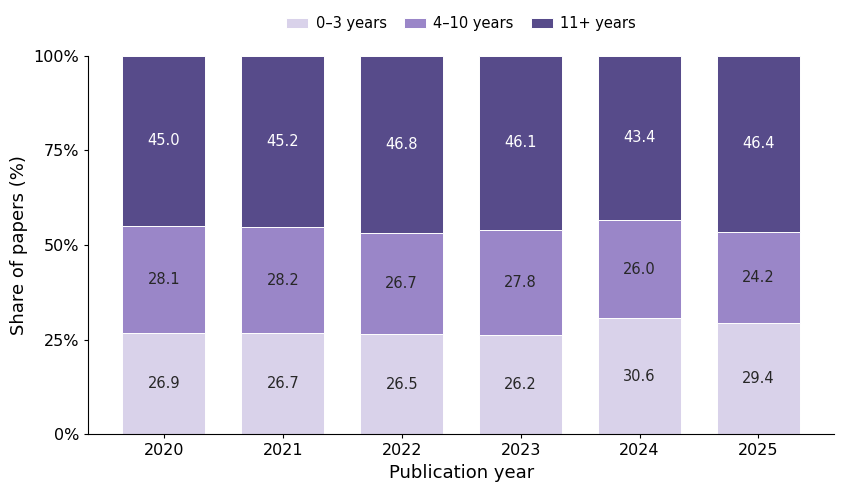

Displayed from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/academic_age_composition.csv


In [20]:
spec = DIMENSIONS["academic_age"]
academic_age_source = SOURCE_DATA_DIR / spec["filename"]
academic_age_figure = plot_composition_from_source(
    academic_age_source,
    categories=spec["categories"],
    colors=spec["colors"],
)
plt.show()
print(f"Displayed from: {academic_age_source}")

## First-author language-environment composition

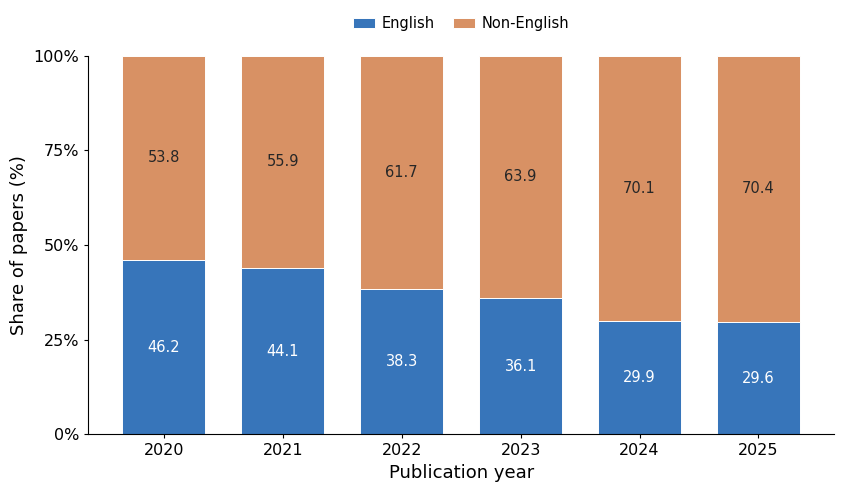

Displayed from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/language_environment_composition.csv


In [21]:
spec = DIMENSIONS["language_environment"]
language_source = SOURCE_DATA_DIR / spec["filename"]
language_figure = plot_composition_from_source(
    language_source,
    categories=spec["categories"],
    colors=spec["colors"],
)
plt.show()
print(f"Displayed from: {language_source}")

## Conference-track composition

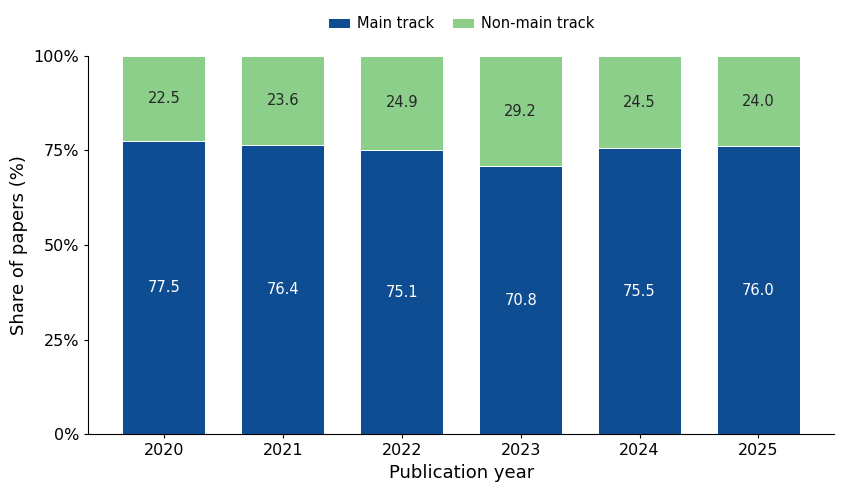

Displayed from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/01_dataset_composition/track_type_composition.csv


In [22]:
spec = DIMENSIONS["track_type"]
track_source = SOURCE_DATA_DIR / spec["filename"]
track_figure = plot_composition_from_source(
    track_source,
    categories=spec["categories"],
    colors=spec["colors"],
)
plt.show()
print(f"Displayed from: {track_source}")